In [1]:
# %%
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tifffile
from skimage.segmentation import find_boundaries


# Find repository root automatically.
for candidate in (
    Path.cwd(),
    *Path.cwd().parents,
):
    if (
        candidate
        / "pyproject.toml"
    ).is_file():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Could not locate the repository root."
    )


DATASET_ROOT = (
    PROJECT_ROOT
    / "data"
    / "cnt_segmentation"
)

IMAGES_DIR = (
    DATASET_ROOT
    / "images"
)

MASKS_DIR = (
    DATASET_ROOT
    / "masks"
)


TARGET_STEM = (
    "400-1293-17-c11k1r5_pd_"
    "sp1_2_fl0_1_right"
)


print("Project root:")
print(PROJECT_ROOT)

print("\nImages directory:")
print(IMAGES_DIR)

print("\nMasks directory:")
print(MASKS_DIR)

Project root:
c:\Users\abd93000\PycharmProjects\cnt_project_v2

Images directory:
c:\Users\abd93000\PycharmProjects\cnt_project_v2\data\cnt_segmentation\images

Masks directory:
c:\Users\abd93000\PycharmProjects\cnt_project_v2\data\cnt_segmentation\masks


In [2]:
# %%
def find_file_by_stem(
    directory: Path,
    stem: str,
) -> Path:
    matches = [
        path
        for path in directory.iterdir()
        if (
            path.is_file()
            and path.stem == stem
        )
    ]

    if len(matches) == 0:
        raise FileNotFoundError(
            f"No file found for:\n"
            f"{stem}\n"
            f"inside:\n"
            f"{directory}"
        )

    if len(matches) > 1:
        raise RuntimeError(
            "Multiple files found:\n"
            + "\n".join(
                str(path)
                for path in matches
            )
        )

    return matches[0]


IMAGE_PATH = find_file_by_stem(
    IMAGES_DIR,
    TARGET_STEM,
)

MASK_PATH = find_file_by_stem(
    MASKS_DIR,
    TARGET_STEM,
)


print("Image:")
print(IMAGE_PATH)

print("\nMask:")
print(MASK_PATH)

Image:
c:\Users\abd93000\PycharmProjects\cnt_project_v2\data\cnt_segmentation\images\400-1293-17-c11k1r5_pd_sp1_2_fl0_1_right.tif

Mask:
c:\Users\abd93000\PycharmProjects\cnt_project_v2\data\cnt_segmentation\masks\400-1293-17-c11k1r5_pd_sp1_2_fl0_1_right.tif


In [3]:
# %%
image = tifffile.imread(
    IMAGE_PATH
)

mask = tifffile.imread(
    MASK_PATH
)


print(
    "Image shape:",
    image.shape,
)

print(
    "Image dtype:",
    image.dtype,
)

print(
    "Mask shape:",
    mask.shape,
)

print(
    "Mask dtype:",
    mask.dtype,
)

print(
    "Mask minimum:",
    mask.min(),
)

print(
    "Mask maximum label:",
    mask.max(),
)

instance_ids = np.unique(
    mask
)

instance_ids = instance_ids[
    instance_ids != 0
]


print(
    "Number of GT objects:",
    len(instance_ids),
)

print(
    "First object IDs:",
    instance_ids[:20],
)

Image shape: (256, 256, 3)
Image dtype: uint8
Mask shape: (256, 256)
Mask dtype: int32
Mask minimum: 0
Mask maximum label: 5
Number of GT objects: 5
First object IDs: [1 2 3 4 5]


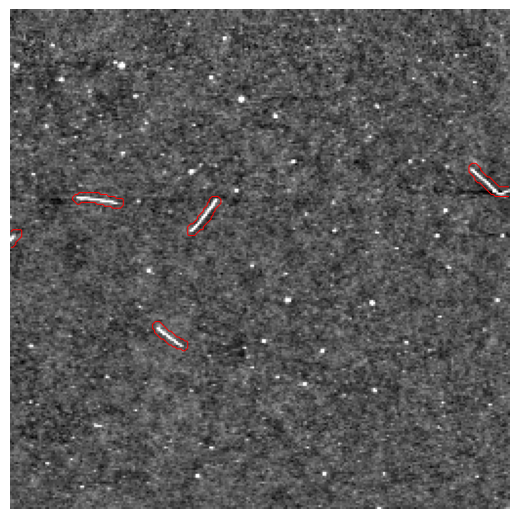

In [4]:
# %%
figure, axis = plt.subplots(
    figsize=(
        5.0,
        5.0,
    )
)


# Display the original AFM image.
if image.ndim == 2:
    axis.imshow(
        image,
        cmap="gray",
    )
else:
    axis.imshow(
        image,
    )


# Draw the contour of every GT instance separately.
for instance_id in instance_ids:
    instance_mask = (
        mask == instance_id
    )

    axis.contour(
        instance_mask.astype(float),
        levels=[
            0.5,
        ],
        colors="red",
        linewidths=0.7,
    )


axis.axis("off")

figure.tight_layout(
    pad=0,
)

plt.show()

In [5]:
# %%
# Select one GT object directly by its instance ID.

SELECTED_INSTANCE_ID = 1


if SELECTED_INSTANCE_ID not in instance_ids:
    raise ValueError(
        f"Instance ID {SELECTED_INSTANCE_ID} "
        "does not exist in this mask.\n"
        f"Available IDs: {instance_ids.tolist()}"
    )


selected_instance_id = (
    SELECTED_INSTANCE_ID
)

selected_mask = (
    mask == selected_instance_id
)


rows, columns = np.nonzero(
    selected_mask
)


centroid_y = float(
    rows.mean()
)

centroid_x = float(
    columns.mean()
)


print(
    "Selected instance ID:",
    selected_instance_id,
)

print(
    "Pixel count:",
    np.count_nonzero(
        selected_mask
    ),
)

print(
    "Centroid:",
    (
        centroid_x,
        centroid_y,
    ),
)

Selected instance ID: 1
Pixel count: 132
Centroid: (44.88636363636363, 97.13636363636364)


In [6]:
# %%
CROP_PADDING = 2


rows, columns = np.nonzero(
    selected_mask
)

if rows.size == 0:
    raise RuntimeError(
        "Selected mask is empty."
    )


# Bounding box of the selected object.
object_row_min = int(
    rows.min()
)

object_row_max = int(
    rows.max()
)

object_col_min = int(
    columns.min()
)

object_col_max = int(
    columns.max()
)


object_height = (
    object_row_max
    - object_row_min
    + 1
)

object_width = (
    object_col_max
    - object_col_min
    + 1
)


# Make the crop square while keeping it
# tightly centered around the selected object.
crop_size = max(
    object_height,
    object_width,
)

crop_size += (
    2 * CROP_PADDING
)


# Do not allow a crop larger than the image.
crop_size = min(
    crop_size,
    mask.shape[0],
    mask.shape[1],
)


# Center of the selected object bounding box.
center_row = (
    object_row_min
    + object_row_max
) / 2.0

center_col = (
    object_col_min
    + object_col_max
) / 2.0


# Initial square crop bounds.
row_start = int(
    round(
        center_row
        - crop_size / 2
    )
)

column_start = int(
    round(
        center_col
        - crop_size / 2
    )
)

row_stop = (
    row_start
    + crop_size
)

column_stop = (
    column_start
    + crop_size
)


# Shift the crop if it crosses image boundaries.
if row_start < 0:
    row_stop -= row_start
    row_start = 0

if column_start < 0:
    column_stop -= column_start
    column_start = 0

if row_stop > mask.shape[0]:
    shift = (
        row_stop
        - mask.shape[0]
    )

    row_start -= shift
    row_stop = mask.shape[0]

if column_stop > mask.shape[1]:
    shift = (
        column_stop
        - mask.shape[1]
    )

    column_start -= shift
    column_stop = mask.shape[1]


# Final safety clamp.
row_start = max(
    row_start,
    0,
)

column_start = max(
    column_start,
    0,
)


image_crop = image[
    row_start:row_stop,
    column_start:column_stop,
]

selected_mask_crop = selected_mask[
    row_start:row_stop,
    column_start:column_stop,
]


print(
    "Selected instance ID:",
    selected_instance_id,
)

print(
    "Object size:",
    (
        object_height,
        object_width,
    ),
)

print(
    "Crop size:",
    crop_size,
)

print(
    "Crop padding:",
    CROP_PADDING,
)

print(
    "Image crop shape:",
    image_crop.shape,
)

Selected instance ID: 1
Object size: (8, 26)
Crop size: 30
Crop padding: 2
Image crop shape: (30, 30, 3)


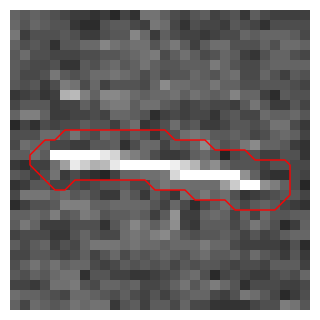

In [7]:
# %%
FIGURE_SIZE = (
    3.0,
    3.0,
)


figure = plt.figure(
    figsize=FIGURE_SIZE,
)

axis = figure.add_axes(
    [
        0.0,
        0.0,
        1.0,
        1.0,
    ]
)


if image_crop.ndim == 2:
    axis.imshow(
        image_crop,
        cmap="gray",
        interpolation="nearest",
    )
else:
    axis.imshow(
        image_crop,
        interpolation="nearest",
    )


axis.contour(
    selected_mask_crop.astype(float),
    levels=[
        0.5,
    ],
    colors="red",
    linewidths=1.0,
)


axis.axis("off")

plt.show()

In [8]:
# %%
import sys

from scipy import ndimage
from stardist.geometry import star_dist


SRC_ROOT = (
    PROJECT_ROOT
    / "src"
)

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(SRC_ROOT),
    )


from cnt_project.model_development.stardist_patched.scoring_functions import (
    edt_standard,
    new_edt,
)

In [9]:
# %%
selected_label_crop = (
    selected_mask_crop.astype(
        np.int32
    )
)


print(
    "Label values:",
    np.unique(
        selected_label_crop
    ),
)

print(
    "Foreground pixels:",
    np.count_nonzero(
        selected_label_crop
    ),
)

print(
    "Shape:",
    selected_label_crop.shape,
)

Label values: [0 1]
Foreground pixels: 132
Shape: (30, 30)


In [10]:
# %%
N_RAYS = 64


radial_distances = star_dist(
    selected_label_crop,
    n_rays=N_RAYS,
)


print(
    "Radial-distance shape:",
    radial_distances.shape,
)

print(
    "Number of rays:",
    radial_distances.shape[-1],
)

print(
    "Minimum distance:",
    radial_distances[
        selected_mask_crop
    ].min(),
)

print(
    "Maximum distance:",
    radial_distances[
        selected_mask_crop
    ].max(),
)

Radial-distance shape: (30, 30, 64)
Number of rays: 64
Minimum distance: 0.5
Maximum distance: 25.502417


In [11]:
# %%
standard_edt_map = edt_standard(
    selected_label_crop,
)

new_edt_map = new_edt(
    selected_label_crop,
    radial_distances,
)


# Keep the background exactly zero.
standard_edt_map = np.where(
    selected_mask_crop,
    standard_edt_map,
    0.0,
)

new_edt_map = np.where(
    selected_mask_crop,
    new_edt_map,
    0.0,
)


print(
    "Standard EDT range:",
    (
        standard_edt_map[
            selected_mask_crop
        ].min(),
        standard_edt_map[
            selected_mask_crop
        ].max(),
    ),
)

print(
    "New EDT range:",
    (
        new_edt_map[
            selected_mask_crop
        ].min(),
        new_edt_map[
            selected_mask_crop
        ].max(),
    ),
)

Standard EDT range: (0.33333334, 1.0)
New EDT range: (0.0, 1.0)


In [12]:
# %%
PEAK_FILTER_SIZE = 3
PEAK_RELATIVE_THRESHOLD = 0.90


def find_strong_local_maxima(
    score_map,
    object_mask,
    *,
    filter_size=3,
    relative_threshold=0.90,
):
    score_map = np.asarray(
        score_map,
        dtype=float,
    )

    object_mask = np.asarray(
        object_mask,
        dtype=bool,
    )


    masked_scores = np.zeros_like(
        score_map,
        dtype=float,
    )

    masked_scores[
        object_mask
    ] = score_map[
        object_mask
    ]


    object_maximum = float(
        masked_scores[
            object_mask
        ].max()
    )


    local_maximum_map = (
        ndimage.maximum_filter(
            masked_scores,
            size=filter_size,
            mode="constant",
        )
    )


    peak_mask = (
        object_mask
        & (
            masked_scores
            == local_maximum_map
        )
        & (
            masked_scores
            >= (
                relative_threshold
                * object_maximum
            )
        )
    )


    peak_coordinates = np.argwhere(
        peak_mask
    )


    return (
        peak_mask,
        peak_coordinates,
        object_maximum,
    )


(
    standard_peak_mask,
    standard_peak_coordinates,
    standard_maximum,
) = find_strong_local_maxima(
    standard_edt_map,
    selected_mask_crop,
    filter_size=PEAK_FILTER_SIZE,
    relative_threshold=PEAK_RELATIVE_THRESHOLD,
)


(
    new_peak_mask,
    new_peak_coordinates,
    new_maximum,
) = find_strong_local_maxima(
    new_edt_map,
    selected_mask_crop,
    filter_size=PEAK_FILTER_SIZE,
    relative_threshold=PEAK_RELATIVE_THRESHOLD,
)


print(
    "Standard EDT strong local-max pixels:",
    len(
        standard_peak_coordinates
    ),
)

print(
    "New EDT strong local-max pixels:",
    len(
        new_peak_coordinates
    ),
)

Standard EDT strong local-max pixels: 12
New EDT strong local-max pixels: 1


In [13]:
# %%
def connected_peak_regions(
    peak_mask,
):
    labels, count = ndimage.label(
        peak_mask,
        structure=np.ones(
            (
                3,
                3,
            ),
            dtype=np.uint8,
        ),
    )

    return (
        labels,
        count,
    )


(
    standard_peak_labels,
    standard_peak_region_count,
) = connected_peak_regions(
    standard_peak_mask
)


(
    new_peak_labels,
    new_peak_region_count,
) = connected_peak_regions(
    new_peak_mask
)


print(
    "Standard EDT:"
)

print(
    "  peak pixels:",
    np.count_nonzero(
        standard_peak_mask
    ),
)

print(
    "  connected peak regions:",
    standard_peak_region_count,
)


print(
    "\nNew EDT:"
)

print(
    "  peak pixels:",
    np.count_nonzero(
        new_peak_mask
    ),
)

print(
    "  connected peak regions:",
    new_peak_region_count,
)

Standard EDT:
  peak pixels: 12
  connected peak regions: 4

New EDT:
  peak pixels: 1
  connected peak regions: 1


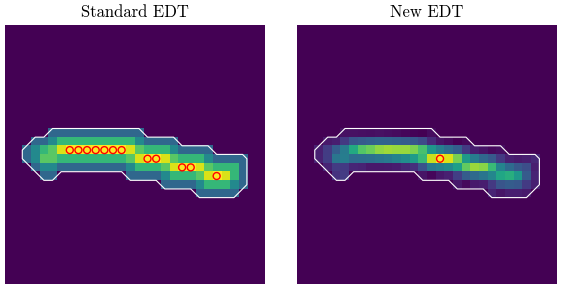

In [14]:
# %%
figure, axes = plt.subplots(
    1,
    2,
    figsize=(
        6.0,
        3.0,
    ),
)


maps = [
    standard_edt_map,
    new_edt_map,
]

peak_masks = [
    standard_peak_mask,
    new_peak_mask,
]

titles = [
    "Standard EDT",
    "New EDT",
]


for (
    axis,
    score_map,
    peak_mask,
    title,
) in zip(
    axes,
    maps,
    peak_masks,
    titles,
):
    image_handle = axis.imshow(
        score_map,
        cmap="viridis",
        vmin=0.0,
        vmax=1.0,
        interpolation="nearest",
    )


    axis.contour(
        selected_mask_crop.astype(float),
        levels=[
            0.5,
        ],
        colors="white",
        linewidths=0.8,
    )


    peak_coordinates = np.argwhere(
        peak_mask
    )

    if len(
        peak_coordinates
    ) > 0:
        axis.scatter(
            peak_coordinates[:, 1],
            peak_coordinates[:, 0],
            s=25,
            facecolors="none",
            edgecolors="red",
            linewidths=1.0,
        )


    axis.set_title(
        title
    )

    axis.axis(
        "off"
    )


figure.tight_layout()

plt.show()

Common grid center: (15, 16)
Grid shape: (7, 15)
Saved: c:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\review\scoring_function_figure\original_afm_crop.svg
Saved: c:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\review\scoring_function_figure\original_afm_crop.png


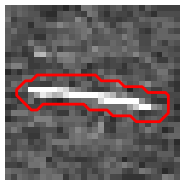

Saved: c:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\review\scoring_function_figure\standard_edt_map.svg
Saved: c:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\review\scoring_function_figure\standard_edt_map.png


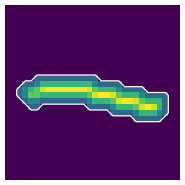

Saved: c:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\review\scoring_function_figure\symmetry_weighted_edt_map.svg
Saved: c:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\review\scoring_function_figure\symmetry_weighted_edt_map.png


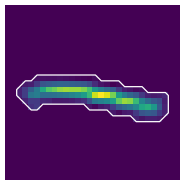

Saved: c:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\review\scoring_function_figure\standard_edt_pixel_scores.svg
Saved: c:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\review\scoring_function_figure\standard_edt_pixel_scores.png


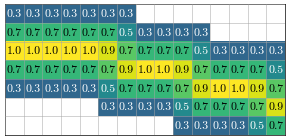

Saved: c:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\review\scoring_function_figure\symmetry_weighted_edt_pixel_scores.svg
Saved: c:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\review\scoring_function_figure\symmetry_weighted_edt_pixel_scores.png


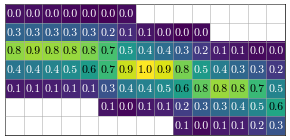

Saved: c:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\review\scoring_function_figure\standard_edt_full_object_pixel_scores.svg
Saved: c:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\review\scoring_function_figure\standard_edt_full_object_pixel_scores.png


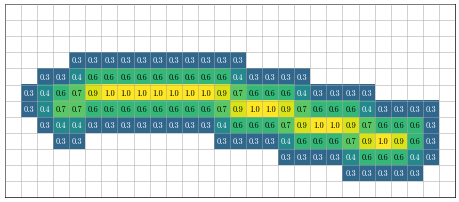

Saved: c:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\review\scoring_function_figure\symmetry_weighted_edt_full_object_pixel_scores.svg
Saved: c:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\review\scoring_function_figure\symmetry_weighted_edt_full_object_pixel_scores.png


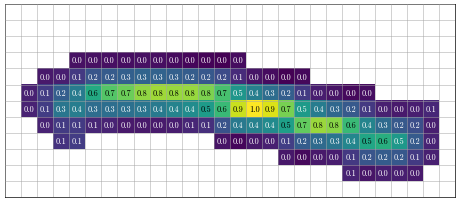

In [30]:
# %%
import scienceplots


# =========================================================
# Publication configuration
# =========================================================

# Preserve text as vector text in PDF/SVG output.
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


ORIGINAL_FIGURE_SIZE = (
    2.3,
    1.75,
)

SCORE_MAP_FIGURE_SIZE = (
    2.3,
    1.75,
)

GRID_FIGURE_SIZE = (
    2.8,
    1.5,
)
FULL_OBJECT_GRID_FIGURE_SIZE = (4.5, 2.6)
FULL_OBJECT_SCORE_FONT_SIZE = 6
SAVE_DPI = 600

GRID_HALF_HEIGHT = 3
GRID_HALF_WIDTH = 7


OUTPUT_DIR = (
    PROJECT_ROOT
    / "notebooks"
    / "review"
    / "scoring_function_figure"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# =========================================================
# Common grid center
# =========================================================

# Use the maximum of the symmetry-weighted score as the
# common spatial reference for BOTH numerical grids.

new_scores_for_center = np.where(
    selected_mask_crop,
    new_edt_map,
    -np.inf,
)

center_row, center_col = np.unravel_index(
    np.argmax(
        new_scores_for_center
    ),
    new_scores_for_center.shape,
)


grid_row_start = max(
    0,
    center_row - GRID_HALF_HEIGHT,
)

grid_row_stop = min(
    selected_mask_crop.shape[0],
    center_row + GRID_HALF_HEIGHT + 1,
)

grid_col_start = max(
    0,
    center_col - GRID_HALF_WIDTH,
)

grid_col_stop = min(
    selected_mask_crop.shape[1],
    center_col + GRID_HALF_WIDTH + 1,
)


standard_grid = standard_edt_map[
    grid_row_start:grid_row_stop,
    grid_col_start:grid_col_stop,
]

new_grid = new_edt_map[
    grid_row_start:grid_row_stop,
    grid_col_start:grid_col_stop,
]

mask_grid = selected_mask_crop[
    grid_row_start:grid_row_stop,
    grid_col_start:grid_col_stop,
]


print(
    "Common grid center:",
    (
        center_row,
        center_col,
    ),
)

print(
    "Grid shape:",
    standard_grid.shape,
)


# =========================================================
# Saving helper
# =========================================================

def save_publication_figure(
    figure,
    stem,
):
    svg_path = (
        OUTPUT_DIR
        / f"{stem}.svg"
    )

    png_path = (
        OUTPUT_DIR
        / f"{stem}.png"
    )


    # Vector version for publication / EPS conversion.
    figure.savefig(
        svg_path,
        format="svg",
        transparent=False,
    )


    # High-resolution raster preview.
    figure.savefig(
        png_path,
        dpi=SAVE_DPI,
        transparent=False,
    )


    print(
        "Saved:",
        svg_path,
    )

    print(
        "Saved:",
        png_path,
    )


# =========================================================
# Original AFM crop helper
# =========================================================

def create_original_crop_figure(
    image_crop,
    object_mask_crop,
):
    figure = plt.figure(
        figsize=ORIGINAL_FIGURE_SIZE,
    )

    axis = figure.add_axes(
        [
            0.0,
            0.0,
            1.0,
            1.0,
        ]
    )


    if image_crop.ndim == 2:
        axis.imshow(
            image_crop,
            cmap="gray",
            interpolation="nearest",
        )
    else:
        axis.imshow(
            image_crop,
            interpolation="nearest",
        )


    # Ground-truth object contour.
    axis.contour(
        object_mask_crop.astype(float),
        levels=[
            0.5,
        ],
        colors="red",
        linewidths=2.0,
    )


    axis.set_xlim(
        -0.5,
        image_crop.shape[1] - 0.5,
    )

    axis.set_ylim(
        image_crop.shape[0] - 0.5,
        -0.5,
    )

    axis.set_aspect(
        "equal"
    )

    axis.axis(
        "off"
    )


    return figure


# =========================================================
# Full score-map helper
# =========================================================

def create_score_map_figure(
    score_map,
):
    figure = plt.figure(
        figsize=SCORE_MAP_FIGURE_SIZE,
    )

    axis = figure.add_axes(
        [
            0.0,
            0.0,
            1.0,
            1.0,
        ]
    )


    axis.imshow(
        score_map,
        cmap="viridis",
        vmin=0.0,
        vmax=1.0,
        interpolation="nearest",
    )


    # GT object boundary.
    axis.contour(
        selected_mask_crop.astype(float),
        levels=[
            0.5,
        ],
        colors="white",
        linewidths=0.9,
    )


    axis.set_xlim(
        -0.5,
        score_map.shape[1] - 0.5,
    )

    axis.set_ylim(
        score_map.shape[0] - 0.5,
        -0.5,
    )

    axis.set_aspect(
        "equal"
    )

    axis.axis(
        "off"
    )


    return figure


# =========================================================
# Pixel-value-grid helper
# =========================================================

def create_score_grid_figure(
    score_grid,
    object_mask_grid,
):
    figure = plt.figure(
        figsize=GRID_FIGURE_SIZE,
    )

    axis = figure.add_axes(
        [
            0.0,
            0.0,
            1.0,
            1.0,
        ]
    )


    # Pixels outside the CNT are hidden.
    masked_scores = np.ma.masked_where(
        ~object_mask_grid,
        score_grid,
    )


    axis.imshow(
        masked_scores,
        cmap="viridis",
        vmin=0.0,
        vmax=1.0,
        interpolation="nearest",
    )


    n_rows, n_cols = (
        score_grid.shape
    )


    # -----------------------------------------------------
    # Actual numerical pixel scores
    # -----------------------------------------------------

    for row in range(
        n_rows
    ):
        for col in range(
            n_cols
        ):
            if not object_mask_grid[
                row,
                col,
            ]:
                continue


            value = float(
                score_grid[
                    row,
                    col,
                ]
            )


            # Improve contrast against the viridis background.
            text_color = (
                "black"
                if value >= 0.55
                else "white"
            )


            axis.text(
                col,
                row,
                f"{value:.1f}",
                ha="center",
                va="center",
                fontsize=8.5,
                color=text_color,
                zorder=5,
            )


    # -----------------------------------------------------
    # Explicit pixel-grid boundaries
    # -----------------------------------------------------

    axis.vlines(
        x=np.arange(
            -0.5,
            n_cols + 0.5,
            1.0,
        ),
        ymin=-0.5,
        ymax=n_rows - 0.5,
        linewidth=0.45,
        color="0.65",
        alpha=0.8,
        zorder=4,
    )

    axis.hlines(
        y=np.arange(
            -0.5,
            n_rows + 0.5,
            1.0,
        ),
        xmin=-0.5,
        xmax=n_cols - 0.5,
        linewidth=0.45,
        color="0.65",
        alpha=0.8,
        zorder=4,
    )

    # No axis ticks or labels.
    axis.set_xticks([])
    axis.set_yticks([])

    axis.set_xlim(
        -0.5,
        n_cols - 0.5,
    )

    axis.set_ylim(
        n_rows - 0.5,
        -0.5,
    )

    axis.set_aspect(
        "equal"
    )

    return figure


# =========================================================
# Full-object pixel-value-grid helper
# =========================================================

def create_full_object_score_grid_figure(
    score_map,
    object_mask,
):
    # -----------------------------------------------------
    # Crop display region
    # -----------------------------------------------------

    score_map = score_map[
        9:-9,
        1:-1,
    ]

    object_mask = object_mask[
        9:-9,
        1:-1,
    ]


    figure = plt.figure(
        figsize=FULL_OBJECT_GRID_FIGURE_SIZE,
    )

    axis = figure.add_axes(
        [
            0.0,
            0.0,
            1.0,
            1.0,
        ]
    )


    # Pixels outside the CNT are hidden.
    masked_scores = np.ma.masked_where(
        ~object_mask,
        score_map,
    )


    axis.imshow(
        masked_scores,
        cmap="viridis",
        vmin=0.0,
        vmax=1.0,
        interpolation="nearest",
    )


    n_rows, n_cols = (
        score_map.shape
    )


    # -----------------------------------------------------
    # Actual numerical pixel scores
    # -----------------------------------------------------

    for row in range(
        n_rows
    ):
        for col in range(
            n_cols
        ):
            if not object_mask[
                row,
                col,
            ]:
                continue


            value = float(
                score_map[
                    row,
                    col,
                ]
            )


            # Truncate rather than round to one decimal.
            display_value = (
                np.trunc(
                    value * 10
                )
                / 10
            )


            text_color = (
                "black"
                if value >= 0.55
                else "white"
            )


            axis.text(
                col,
                row,
                f"{display_value:.1f}",
                ha="center",
                va="center",
                fontsize=FULL_OBJECT_SCORE_FONT_SIZE ,
                color=text_color,
                zorder=5,
            )


    # -----------------------------------------------------
    # Explicit pixel-grid boundaries
    # -----------------------------------------------------

    axis.vlines(
        x=np.arange(
            -0.5,
            n_cols + 0.5,
            1.0,
        ),
        ymin=-0.5,
        ymax=n_rows - 0.5,
        linewidth=0.45,
        color="0.65",
        alpha=0.8,
        zorder=4,
    )

    axis.hlines(
        y=np.arange(
            -0.5,
            n_rows + 0.5,
            1.0,
        ),
        xmin=-0.5,
        xmax=n_cols - 0.5,
        linewidth=0.45,
        color="0.65",
        alpha=0.8,
        zorder=4,
    )


    axis.set_xticks([])
    axis.set_yticks([])


    axis.set_xlim(
        -0.5,
        n_cols - 0.5,
    )

    axis.set_ylim(
        n_rows - 0.5,
        -0.5,
    )

    axis.set_aspect(
        "equal"
    )


    return figure
# =========================================================
# Generate all five figures using SciencePlots
# =========================================================

with plt.style.context(
    [
        "science",
        "no-latex",
    ]
):

    # -----------------------------------------------------
    # Figure 1 — Original AFM crop
    # -----------------------------------------------------

    figure_1 = create_original_crop_figure(
        image_crop,
        selected_mask_crop,
    )

    save_publication_figure(
        figure_1,
        "original_afm_crop",
    )

    plt.show()


    # -----------------------------------------------------
    # Figure 2 — Standard EDT
    # -----------------------------------------------------

    figure_2 = create_score_map_figure(
        standard_edt_map
    )

    save_publication_figure(
        figure_2,
        "standard_edt_map",
    )

    plt.show()


    # -----------------------------------------------------
    # Figure 3 — Symmetry-weighted EDT
    # -----------------------------------------------------

    figure_3 = create_score_map_figure(
        new_edt_map
    )

    save_publication_figure(
        figure_3,
        "symmetry_weighted_edt_map",
    )

    plt.show()


    # -----------------------------------------------------
    # Figure 4 — Standard EDT pixel scores
    # -----------------------------------------------------

    figure_4 = create_score_grid_figure(
        standard_grid,
        mask_grid,
    )

    save_publication_figure(
        figure_4,
        "standard_edt_pixel_scores",
    )

    plt.show()


    # -----------------------------------------------------
    # Figure 5 — Symmetry-weighted EDT pixel scores
    # -----------------------------------------------------

    figure_5 = create_score_grid_figure(
        new_grid,
        mask_grid,
    )

    save_publication_figure(
        figure_5,
        "symmetry_weighted_edt_pixel_scores",
    )

    plt.show()
        # -----------------------------------------------------
    # Figure 6 — Standard EDT full-object pixel scores
    # -----------------------------------------------------

    figure_6 = create_full_object_score_grid_figure(
        standard_edt_map,
        selected_mask_crop,
    )

    save_publication_figure(
        figure_6,
        "standard_edt_full_object_pixel_scores",
    )

    plt.show()


    # -----------------------------------------------------
    # Figure 7 — Symmetry-weighted EDT full-object scores
    # -----------------------------------------------------

    figure_7 = create_full_object_score_grid_figure(
        new_edt_map,
        selected_mask_crop,
    )

    save_publication_figure(
        figure_7,
        "symmetry_weighted_edt_full_object_pixel_scores",
    )

    plt.show()

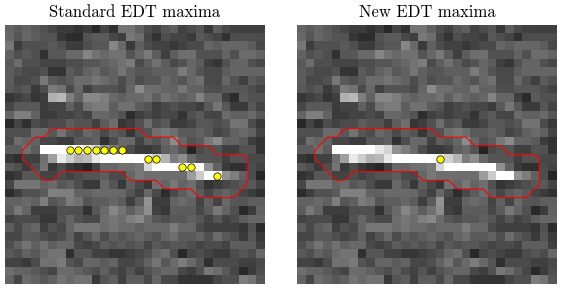

In [16]:
# %%
figure, axes = plt.subplots(
    1,
    2,
    figsize=(
        6.0,
        3.0,
    ),
)


peak_masks = [
    standard_peak_mask,
    new_peak_mask,
]

titles = [
    "Standard EDT maxima",
    "New EDT maxima",
]


for (
    axis,
    peak_mask,
    title,
) in zip(
    axes,
    peak_masks,
    titles,
):
    if image_crop.ndim == 2:
        axis.imshow(
            image_crop,
            cmap="gray",
            interpolation="nearest",
        )
    else:
        axis.imshow(
            image_crop,
            interpolation="nearest",
        )


    axis.contour(
        selected_mask_crop.astype(float),
        levels=[
            0.5,
        ],
        colors="red",
        linewidths=0.8,
    )


    peak_coordinates = np.argwhere(
        peak_mask
    )


    if len(
        peak_coordinates
    ) > 0:
        axis.scatter(
            peak_coordinates[:, 1],
            peak_coordinates[:, 0],
            s=28,
            facecolors="yellow",
            edgecolors="black",
            linewidths=0.5,
        )


    axis.set_title(
        title
    )

    axis.axis(
        "off"
    )


figure.tight_layout()

plt.show()

In [17]:
# %%
HIGH_SCORE_THRESHOLDS = (
    0.90,
    0.80,
    0.70,
    0.60,
)


def high_score_statistics(
    score_map,
    object_mask,
    thresholds,
):
    score_map = np.asarray(
        score_map,
        dtype=float,
    )

    object_mask = np.asarray(
        object_mask,
        dtype=bool,
    )

    object_scores = score_map[
        object_mask
    ]

    maximum = float(
        object_scores.max()
    )

    rows = []

    for threshold in thresholds:
        high_score_mask = (
            object_mask
            & (
                score_map
                >= threshold * maximum
            )
        )

        pixel_count = int(
            np.count_nonzero(
                high_score_mask
            )
        )

        fraction = (
            pixel_count
            / np.count_nonzero(
                object_mask
            )
        )

        rows.append(
            {
                "relative_threshold": threshold,
                "pixel_count": pixel_count,
                "fraction_of_object": fraction,
            }
        )

    return rows


standard_high_score_stats = (
    high_score_statistics(
        standard_edt_map,
        selected_mask_crop,
        HIGH_SCORE_THRESHOLDS,
    )
)

new_high_score_stats = (
    high_score_statistics(
        new_edt_map,
        selected_mask_crop,
        HIGH_SCORE_THRESHOLDS,
    )
)


print("Standard EDT")

for row in standard_high_score_stats:
    print(
        f"  >= {row['relative_threshold']:.0%}: "
        f"{row['pixel_count']} pixels "
        f"({row['fraction_of_object']:.1%} of object)"
    )


print("\nNew EDT")

for row in new_high_score_stats:
    print(
        f"  >= {row['relative_threshold']:.0%}: "
        f"{row['pixel_count']} pixels "
        f"({row['fraction_of_object']:.1%} of object)"
    )

Standard EDT
  >= 90%: 20 pixels (15.2% of object)
  >= 80%: 20 pixels (15.2% of object)
  >= 70%: 29 pixels (22.0% of object)
  >= 60%: 66 pixels (50.0% of object)

New EDT
  >= 90%: 3 pixels (2.3% of object)
  >= 80%: 10 pixels (7.6% of object)
  >= 70%: 15 pixels (11.4% of object)
  >= 60%: 19 pixels (14.4% of object)


In [18]:
# %%
HIGH_SCORE_THRESHOLD = 0.80


standard_high_score_mask = (
    selected_mask_crop
    & (
        standard_edt_map
        >= (
            HIGH_SCORE_THRESHOLD
            * standard_edt_map[
                selected_mask_crop
            ].max()
        )
    )
)


new_high_score_mask = (
    selected_mask_crop
    & (
        new_edt_map
        >= (
            HIGH_SCORE_THRESHOLD
            * new_edt_map[
                selected_mask_crop
            ].max()
        )
    )
)


print(
    "Standard EDT high-score pixels:",
    np.count_nonzero(
        standard_high_score_mask
    ),
)

print(
    "New EDT high-score pixels:",
    np.count_nonzero(
        new_high_score_mask
    ),
)

Standard EDT high-score pixels: 20
New EDT high-score pixels: 10


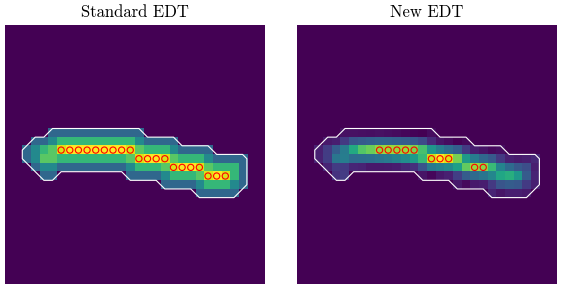

In [19]:
# %%
figure, axes = plt.subplots(
    1,
    2,
    figsize=(
        6.0,
        3.0,
    ),
)


maps = [
    standard_edt_map,
    new_edt_map,
]

high_score_masks = [
    standard_high_score_mask,
    new_high_score_mask,
]

titles = [
    "Standard EDT",
    "New EDT",
]


for (
    axis,
    score_map,
    high_score_mask,
    title,
) in zip(
    axes,
    maps,
    high_score_masks,
    titles,
):
    axis.imshow(
        score_map,
        cmap="viridis",
        vmin=0.0,
        vmax=1.0,
        interpolation="nearest",
    )

    axis.contour(
        selected_mask_crop.astype(float),
        levels=[
            0.5,
        ],
        colors="white",
        linewidths=0.8,
    )

    coordinates = np.argwhere(
        high_score_mask
    )

    if len(coordinates) > 0:
        axis.scatter(
            coordinates[:, 1],
            coordinates[:, 0],
            s=20,
            facecolors="none",
            edgecolors="red",
            linewidths=0.8,
        )

    axis.set_title(
        title
    )

    axis.axis(
        "off"
    )


figure.tight_layout()

plt.show()

In [20]:
# %%
HIGH_SCORE_THRESHOLD = 0.80


def get_high_score_mask(
    score_map,
    object_mask,
    threshold,
):
    maximum = float(
        score_map[
            object_mask
        ].max()
    )

    return (
        object_mask
        & (
            score_map
            >= threshold * maximum
        )
    )


standard_high_score_mask = (
    get_high_score_mask(
        standard_edt_map,
        selected_mask_crop,
        HIGH_SCORE_THRESHOLD,
    )
)

new_high_score_mask = (
    get_high_score_mask(
        new_edt_map,
        selected_mask_crop,
        HIGH_SCORE_THRESHOLD,
    )
)


object_pixel_count = np.count_nonzero(
    selected_mask_crop
)

standard_high_count = np.count_nonzero(
    standard_high_score_mask
)

new_high_count = np.count_nonzero(
    new_high_score_mask
)


standard_high_fraction = (
    standard_high_count
    / object_pixel_count
)

new_high_fraction = (
    new_high_count
    / object_pixel_count
)


concentration_ratio = (
    standard_high_count
    / new_high_count
)


print(
    "Standard EDT:"
)

print(
    f"  high-score pixels: "
    f"{standard_high_count}"
)

print(
    f"  fraction of object: "
    f"{standard_high_fraction:.1%}"
)


print(
    "\nNew EDT:"
)

print(
    f"  high-score pixels: "
    f"{new_high_count}"
)

print(
    f"  fraction of object: "
    f"{new_high_fraction:.1%}"
)


print(
    "\nStandard / New high-score area ratio:"
)

print(
    f"  {concentration_ratio:.2f}x"
)

Standard EDT:
  high-score pixels: 20
  fraction of object: 15.2%

New EDT:
  high-score pixels: 10
  fraction of object: 7.6%

Standard / New high-score area ratio:
  2.00x


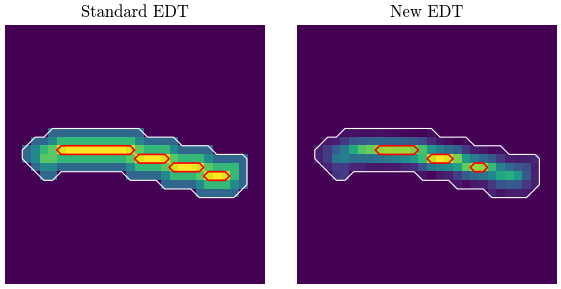

In [21]:
# %%
figure, axes = plt.subplots(
    1,
    2,
    figsize=(
        6.0,
        3.0,
    ),
)


score_maps = [
    standard_edt_map,
    new_edt_map,
]

high_score_masks = [
    standard_high_score_mask,
    new_high_score_mask,
]

titles = [
    "Standard EDT",
    "New EDT",
]


for (
    axis,
    score_map,
    high_score_mask,
    title,
) in zip(
    axes,
    score_maps,
    high_score_masks,
    titles,
):
    axis.imshow(
        score_map,
        cmap="viridis",
        vmin=0.0,
        vmax=1.0,
        interpolation="nearest",
    )


    # GT object boundary.
    axis.contour(
        selected_mask_crop.astype(float),
        levels=[
            0.5,
        ],
        colors="white",
        linewidths=0.8,
    )


    # Boundary of the >= 80% high-score region.
    axis.contour(
        high_score_mask.astype(float),
        levels=[
            0.5,
        ],
        colors="red",
        linewidths=1.2,
    )


    axis.set_title(
        title
    )

    axis.axis(
        "off"
    )


figure.tight_layout()

plt.show()

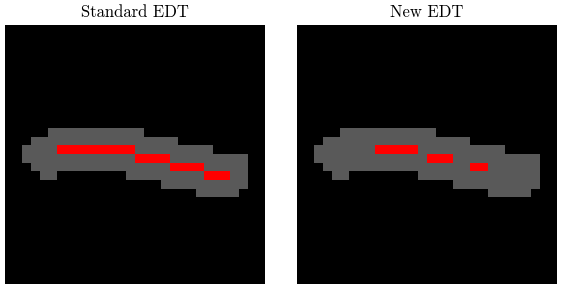

In [22]:
# %%
figure, axes = plt.subplots(
    1,
    2,
    figsize=(
        6.0,
        3.0,
    ),
)


high_score_masks = [
    standard_high_score_mask,
    new_high_score_mask,
]

titles = [
    "Standard EDT",
    "New EDT",
]


for (
    axis,
    high_score_mask,
    title,
) in zip(
    axes,
    high_score_masks,
    titles,
):
    display = np.zeros(
        (
            selected_mask_crop.shape[0],
            selected_mask_crop.shape[1],
            3,
        ),
        dtype=float,
    )


    # Entire CNT in gray.
    display[
        selected_mask_crop
    ] = [
        0.35,
        0.35,
        0.35,
    ]


    # >=80%-of-maximum region in red.
    display[
        high_score_mask
    ] = [
        1.0,
        0.0,
        0.0,
    ]


    axis.imshow(
        display,
        interpolation="nearest",
    )

    axis.set_title(
        title
    )

    axis.axis(
        "off"
    )


figure.tight_layout()

plt.show()